# Notebook 03 — Spatio-Temporal Analysis
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D3 Part 1 — Geographic & Time-Based Complaint Pattern Detection  

---
## Table of Contents
1. Setup & Chargement
2. Geographic Hotspot Analysis
3. Temporal Pattern Analysis
4. Hour × Day-of-Week Heatmap
5. Anomaly Burst Detection
6. Service-Type Segmentation by Region
7. Cell-Level Hotspot Analysis
8. Synthèse

## 1. Setup & Chargement

In [38]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS  = sns.color_palette('husl', 10)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)
print('Setup OK')

Setup OK


## 2. Load Data

In [39]:
# Charger les datasets traités
complaints_clean = pd.read_parquet('data/processed/complaints_clean.parquet')
complaint_agg    = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg          = pd.read_parquet('data/processed/kpi_daily_agg.parquet')

complaints_clean['timestamp'] = pd.to_datetime(complaints_clean['timestamp'])
complaint_agg['date']         = pd.to_datetime(complaint_agg['date'])

print(f'complaints_clean : {complaints_clean.shape}')
print(f'complaint_agg    : {complaint_agg.shape}')
print(f'kpi_agg          : {kpi_agg.shape}')

complaints_clean : (25727, 25)
complaint_agg    : (8088, 21)
kpi_agg          : (8088, 108)


In [40]:
# Lancer le module spatio-temporel complet
from src.analysis.spatiotemporal import SpatioTemporalAnalyser
st      = SpatioTemporalAnalyser()
results = st.run(complaints_clean, complaint_agg, kpi_agg)

2026-05-04 05:57:42.512 | INFO     | src.analysis.spatiotemporal:run:103 - ============================================================
2026-05-04 05:57:42.515 | INFO     | src.analysis.spatiotemporal:run:104 - SPATIO-TEMPORAL ANALYSIS
2026-05-04 05:57:42.517 | INFO     | src.analysis.spatiotemporal:run:105 - ============================================================
2026-05-04 05:57:42.553 | INFO     | src.analysis.spatiotemporal:run:134 - 
[1/6] Geographic hotspot mapping ...
2026-05-04 05:57:42.745 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:262 -   Regional hotspot ranking:
2026-05-04 05:57:42.747 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:264 -     #1 Tunis Gouvernorat  2,859 complaints  QoE=65.8
2026-05-04 05:57:42.748 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:264 -     #2 Sfax Gouvernorat  2,243 complaints  QoE=66.3
2026-05-04 05:57:42.749 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:264 -     #3 Ben Aro

## 2. Geographic Hotspot Analysis

In [41]:
from IPython.display import display, HTML

regional = results['regional_hotspots']

def style_critical(val, col):
    """Colorie les valeurs critiques"""
    if col == 'high_priority_pct' and val > 0.3:
        return 'background-color: #ffcccc'
    elif col == 'avg_qoe_score' and val < 50:
        return 'background-color: #ffcccc'
    elif col == 'total_complaints' and val > regional['total_complaints'].median():
        return 'background-color: #ffffcc'
    return ''

display_df = regional[[
    'hotspot_rank', 'region', 'total_complaints',
    'complaint_rate_per_day', 'dominant_category',
    'dominant_service', 'avg_qoe_score', 'high_priority_pct'
]].copy()

display_df.columns = ['Rang', 'Région', 'Total', 'Taux/jour', 'Catégorie', 'Service', 'QoE', 'Priorité%']
display_df['Priorité%'] = (display_df['Priorité%']).round(1)

# ✅ Correction
styled = (display_df.style
    .applymap(lambda x: 'background-color: #ffffcc'
              if isinstance(x, (int,float)) and x > regional['total_complaints'].median()
              else '', subset=['Total'])
    .applymap(lambda x: 'background-color: #ffcccc'
              if isinstance(x, (int,float)) and x < 50 else '', subset=['QoE'])
    .applymap(lambda x: 'background-color: #ffcccc'
              if isinstance(x, (int,float)) and x > 30 else '', subset=['Priorité%'])
)

display(styled)

,Rang,Région,Total,Taux/jour,Catégorie,Service,QoE,Priorité%
22,1,Tunis Gouvernorat,2859,8.510000,Other,Data,65.830000,0.000000
16,2,Sfax Gouvernorat,2243,6.680000,Other,Data,66.330000,0.000000
1,3,Ben Arous Gouvernorat,2004,5.960000,Other,Data,64.590000,0.000000
15,4,Nabeul Gouvernorat,1620,4.820000,Other,Data,63.000000,0.000000
0,5,Ariana Gouvernorat,1279,3.810000,Other,Data,62.740000,0.000000
19,6,Sousse Gouvernorat,1215,3.620000,Other,Data,59.610000,0.000000
13,7,Mednine Gouvernorat,1189,3.540000,Other,Data,61.210000,0.000000
2,8,Bizerte Gouvernorat,1155,3.440000,Other,Data,61.200000,0.000000
5,9,Gafsa Gouvernorat,1089,3.240000,Other,Data,57.900000,0.000000
12,10,Manouba Gouvernorat,937,2.790000,Other,Data,59.810000,0.000000


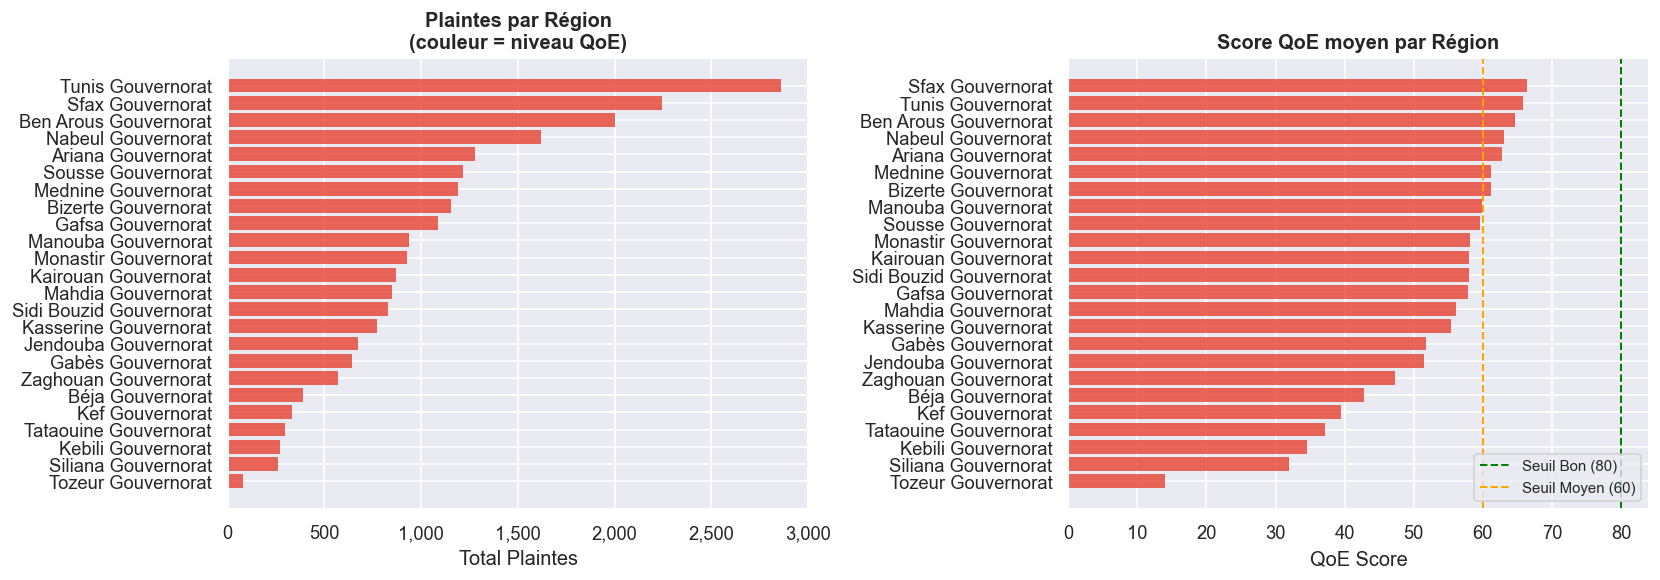

In [42]:
# 2.1 Volume + QoE par région
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_sorted = regional.sort_values('total_complaints')
qoe_vals   = reg_sorted.get('avg_qoe_score', pd.Series([75]*len(reg_sorted)))
bar_colors = ['#e74c3c' if q < 75 else '#f39c12' if q < 82
              else '#2ecc71' for q in qoe_vals]

axes[0].barh(reg_sorted['region'], reg_sorted['total_complaints'],
             color=bar_colors, edgecolor='none', alpha=0.85)
axes[0].set_title('Plaintes par Région\n(couleur = niveau QoE)', fontweight='bold')
axes[0].set_xlabel('Total Plaintes')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

if 'avg_qoe_score' in regional.columns:
    reg_qoe    = regional.sort_values('avg_qoe_score')
    qoe_colors = ['#e74c3c' if q < 75 else '#f39c12' if q < 82
                  else '#2ecc71' for q in reg_qoe['avg_qoe_score']]
    axes[1].barh(reg_qoe['region'], reg_qoe['avg_qoe_score'],
                 color=qoe_colors, edgecolor='none', alpha=0.85)
    axes[1].axvline(80, color='green',  linestyle='--', lw=1.2, label='Seuil Bon (80)')
    axes[1].axvline(60, color='orange', linestyle='--', lw=1.2, label='Seuil Moyen (60)')
    axes[1].set_title('Score QoE moyen par Région', fontweight='bold')
    axes[1].set_xlabel('QoE Score')
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/st_regional_complaints_qoe.png', dpi=150, bbox_inches='tight')
plt.show()

Régions dans 'regional' :
  'Tunis Gouvernorat' → clé='tunis gouvernorat' → ✗ MANQUANT
  'Sfax Gouvernorat' → clé='sfax gouvernorat' → ✗ MANQUANT
  'Ben Arous Gouvernorat' → clé='ben arous gouvernorat' → ✗ MANQUANT
  'Nabeul Gouvernorat' → clé='nabeul gouvernorat' → ✗ MANQUANT
  'Ariana Gouvernorat' → clé='ariana gouvernorat' → ✗ MANQUANT
  'Sousse Gouvernorat' → clé='sousse gouvernorat' → ✗ MANQUANT
  'Mednine Gouvernorat' → clé='mednine gouvernorat' → ✗ MANQUANT
  'Bizerte Gouvernorat' → clé='bizerte gouvernorat' → ✗ MANQUANT
  'Gafsa Gouvernorat' → clé='gafsa gouvernorat' → ✗ MANQUANT
  'Manouba Gouvernorat' → clé='manouba gouvernorat' → ✗ MANQUANT
  'Monastir Gouvernorat' → clé='monastir gouvernorat' → ✗ MANQUANT
  'Kairouan Gouvernorat' → clé='kairouan gouvernorat' → ✗ MANQUANT
  'Mahdia Gouvernorat' → clé='mahdia gouvernorat' → ✗ MANQUANT
  'Sidi Bouzid Gouvernorat' → clé='sidi bouzid gouvernorat' → ✗ MANQUANT
  'Kasserine Gouvernorat' → clé='kasserine gouvernorat' → ✗ MANQUANT
 

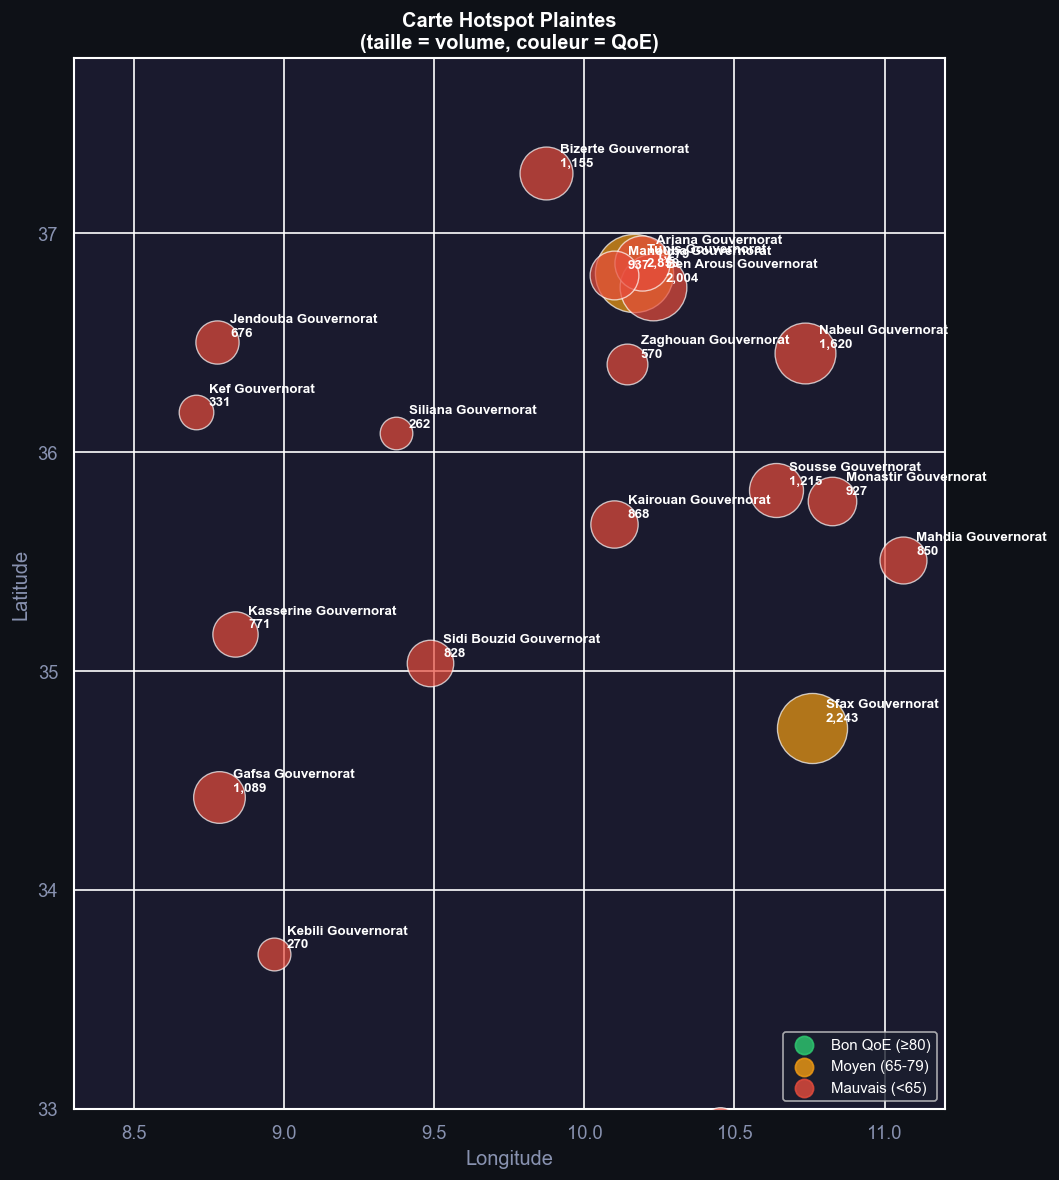

Régions affichées : 21/24


In [43]:
CENTROIDS = {
    'tunis':     (36.818, 10.165), 'ariana':   (36.862, 10.193),
    'ben arous': (36.753, 10.228), 'benarous': (36.753, 10.228),
    'bizerte':   (37.275,  9.873), 'sousse':   (35.825, 10.638),
    'monastir':  (35.777, 10.826), 'sfax':     (34.740, 10.760),
    'kairouan':  (35.671, 10.100), 'gabes':    (33.881, 10.097),
    'gafsa':     (34.422,  8.784), 'nabeul':   (36.451, 10.736),
    'manouba':   (36.810, 10.100), 'zaghouan': (36.402, 10.143),
    'beja':      (36.733,  9.182), 'jendouba': (36.501,  8.776),
    'kef':       (36.182,  8.705), 'siliana':  (36.085,  9.372),
    'mahdia':    (35.505, 11.062), 'sidi bouzid': (35.038,  9.485),
    'kasserine': (35.167,  8.836), 'gafsa':    (34.422,  8.784),
    'tozeur':    (33.920,  8.134), 'kebili':   (33.705,  8.965),
    'tataouine': (32.929, 10.452), 'medenine': (33.354, 10.501),
}

# ── Debug : afficher les régions trouvées / non trouvées ─────────────────
print("Régions dans 'regional' :")
for _, row in regional.iterrows():
    key = str(row['region']).lower().strip()
    found = key in CENTROIDS
    print(f"  '{row['region']}' → clé='{key}' → {'✓' if found else '✗ MANQUANT'}")
print()

fig, ax = plt.subplots(figsize=(9, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0e1117')

max_c   = regional['total_complaints'].max()
plotted = 0

for _, row in regional.iterrows():
    region = str(row['region']).strip()
    key    = region.lower()

    # Cherche lat/lon dans la colonne, puis dans CENTROIDS (insensible casse)
    lat = row.get('lat') if 'lat' in regional.columns else None
    lon = row.get('lon') if 'lon' in regional.columns else None

    if pd.isna(lat) or pd.isna(lon) or lat is None or lon is None:
        coords = CENTROIDS.get(key)
        if coords is None:
            # Tentative de match partiel
            coords = next((v for k, v in CENTROIDS.items()
                           if k in key or key in k), None)
        if coords is None:
            print(f"  ⚠️  Région ignorée (centroïde inconnu) : '{region}'")
            continue
        lat, lon = coords

    count = int(row['total_complaints'])
    qoe   = row.get('avg_qoe_score', 70)
    if pd.isna(qoe): qoe = 70

    size  = 200 + (count / max_c) * 2000
    color = '#2ecc71' if qoe >= 80 else '#f39c12' if qoe >= 65 else '#e74c3c'

    ax.scatter(lon, lat, s=size, color=color,
               alpha=0.7, edgecolors='white', linewidths=0.8, zorder=5)
    ax.annotate(f"{region}\n{count:,}", (lon, lat),
                textcoords='offset points', xytext=(8, 4),
                color='white', fontsize=8, fontweight='bold', zorder=6)
    plotted += 1

ax.set_xlim(8.3, 11.2)
ax.set_ylim(33.0, 37.8)
ax.set_title('Carte Hotspot Plaintes\n(taille = volume, couleur = QoE)',
             color='white', fontweight='bold', fontsize=12)
ax.set_xlabel('Longitude', color='#8892b0')
ax.set_ylabel('Latitude',  color='#8892b0')
ax.tick_params(colors='#8892b0')
for label, color in [('Bon QoE (≥80)', '#2ecc71'),
                      ('Moyen (65-79)', '#f39c12'),
                      ('Mauvais (<65)', '#e74c3c')]:
    ax.scatter([], [], c=color, s=120, label=label, alpha=0.8)
ax.legend(loc='lower right', facecolor='#1a1f2e', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_bubble_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Régions affichées : {plotted}/{len(regional)}')

## 3. Temporal Pattern Analysis

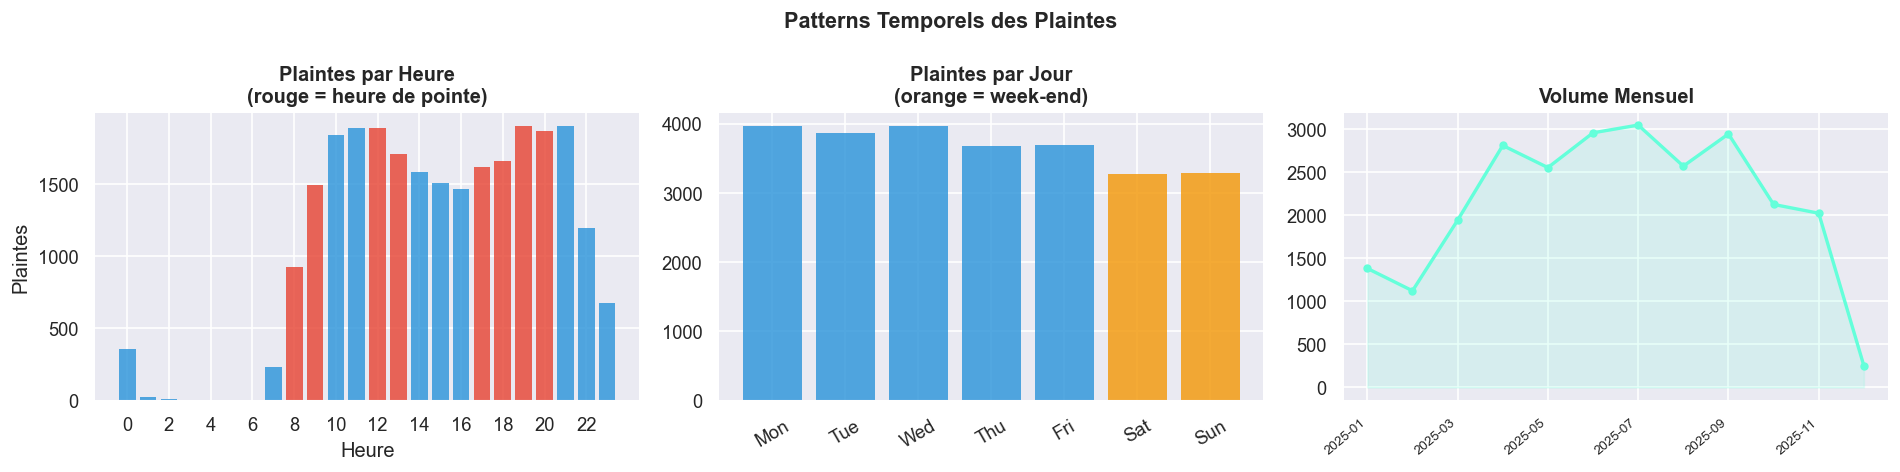

Heure de pointe : 19h00  |  Ratio peak/off-peak : 1.03x


In [44]:
hourly  = results['hourly_patterns']
dow     = results['dow_patterns']
monthly = results['monthly_trends']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Horaire
bar_c = ['#e74c3c' if row['is_peak'] else '#3498db'
          for _, row in hourly.iterrows()]
axes[0].bar(hourly['hour'], hourly['complaint_count'],
            color=bar_c, edgecolor='none', alpha=0.85)
axes[0].set_title('Plaintes par Heure\n(rouge = heure de pointe)', fontweight='bold')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('Plaintes')
axes[0].set_xticks(range(0, 24, 2))

# Jour de la semaine
dow_c = ['#f39c12' if w else '#3498db' for w in dow['is_weekend']]
axes[1].bar(range(len(dow)), dow['complaint_count'],
            color=dow_c, edgecolor='none', alpha=0.85)
axes[1].set_xticks(range(len(dow)))
axes[1].set_xticklabels([d[:3] for d in dow['day_of_week']], rotation=30)
axes[1].set_title('Plaintes par Jour\n(orange = week-end)', fontweight='bold')

# Tendance mensuelle
if 'total' in monthly.columns:
    axes[2].plot(range(len(monthly)), monthly['total'],
                 marker='o', markersize=4, color='#64ffda', linewidth=2)
    axes[2].fill_between(range(len(monthly)), monthly['total'],
                          alpha=0.15, color='#64ffda')
    axes[2].set_xticks(range(0, len(monthly), 2))
    axes[2].set_xticklabels(monthly['month_label'].iloc[::2],
                             rotation=40, ha='right', fontsize=8)
    axes[2].set_title('Volume Mensuel', fontweight='bold')

plt.suptitle('Patterns Temporels des Plaintes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

peak_h = int(hourly.loc[hourly['complaint_count'].idxmax(), 'hour'])
ratio  = hourly['peak_vs_offpeak_ratio'].iloc[0]
print(f'Heure de pointe : {peak_h:02d}h00  |  Ratio peak/off-peak : {ratio:.2f}x')

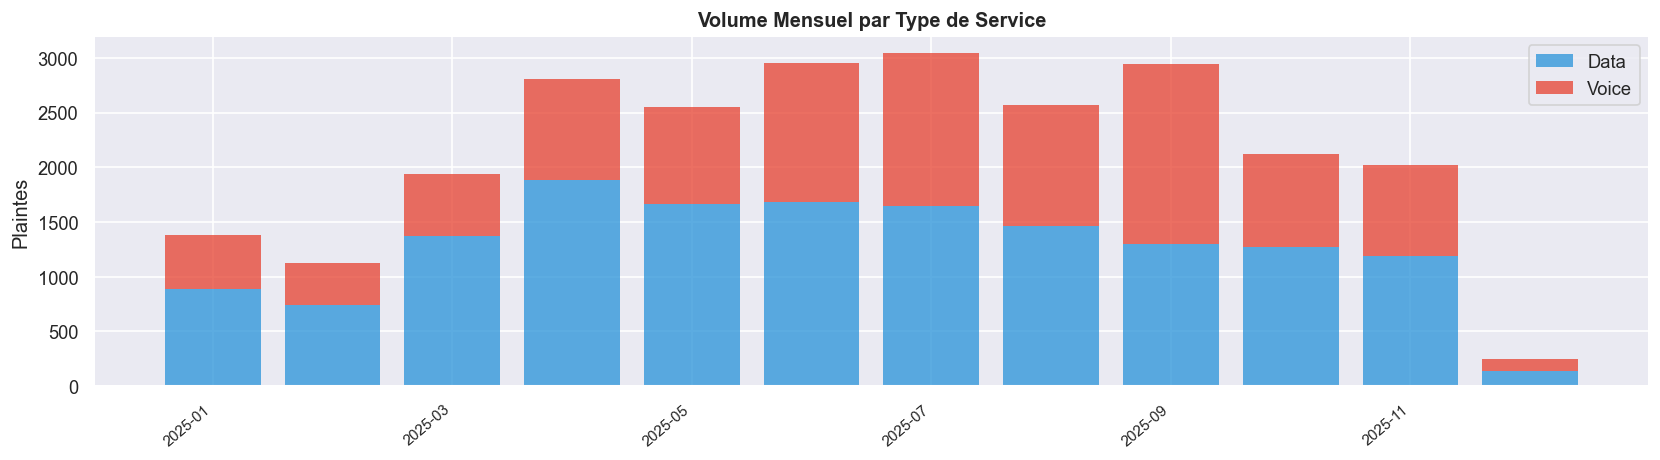

In [45]:
# Volume mensuel par service type (Data vs Voice)
svc_cols = [c for c in monthly.columns
            if c not in ('month_label','total') and not c.endswith('_pct')]

if svc_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    x      = range(len(monthly))
    bottom = np.zeros(len(monthly))
    palette = {'Data':'#3498db','Voice':'#e74c3c','Unknown':'#95a5a6','SMS':'#2ecc71'}
    for col in svc_cols:
        color = palette.get(col, '#9b59b6')
        ax.bar(x, monthly[col], bottom=bottom, label=col,
               color=color, alpha=0.8, edgecolor='none')
        bottom += monthly[col].values
    ax.set_xticks(range(0, len(monthly), 2))
    ax.set_xticklabels(monthly['month_label'].iloc[::2],
                        rotation=40, ha='right', fontsize=9)
    ax.set_title('Volume Mensuel par Type de Service', fontweight='bold')
    ax.set_ylabel('Plaintes'); ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_monthly_service_stacked.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Hour × Day-of-Week Heatmap

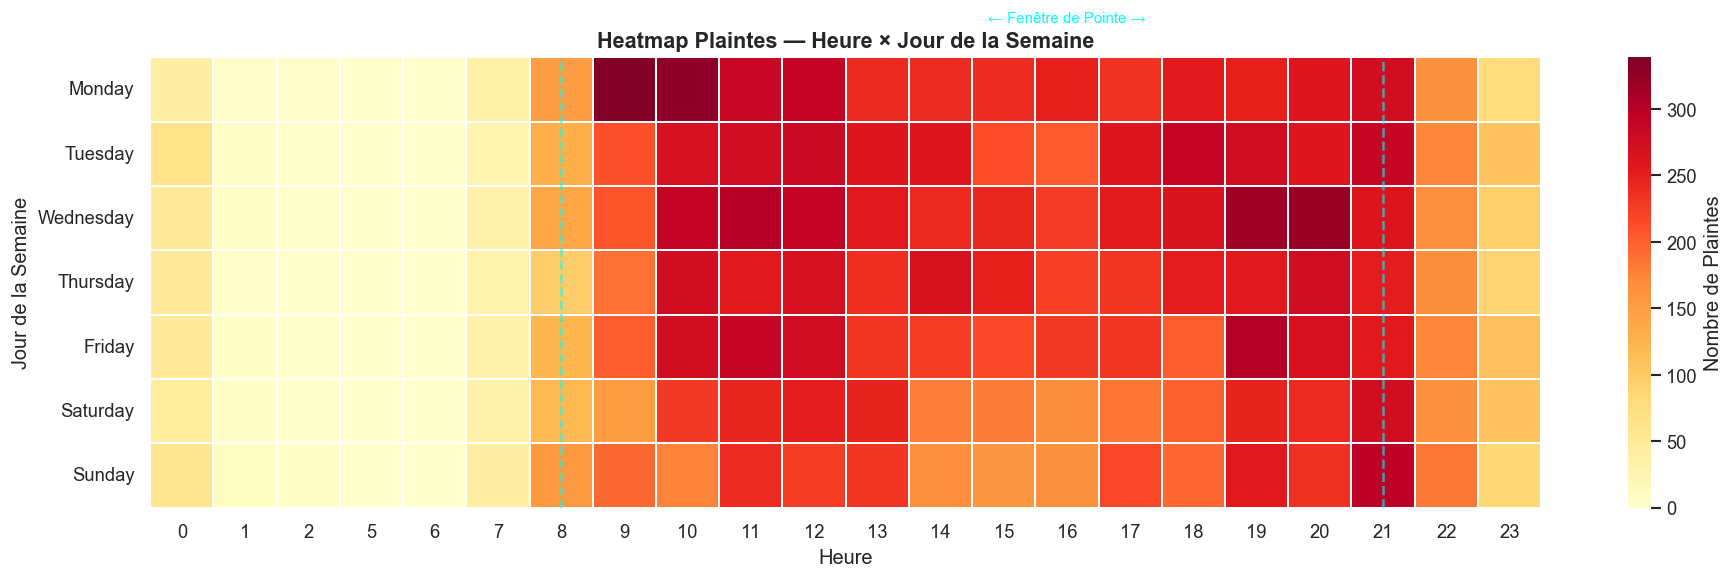

In [46]:
hour_dow = results['hour_dow_heatmap']
cols = list(hour_dow.columns)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hour_dow, cmap='YlOrRd', linewidths=0.2, ax=ax,
            cbar_kws={'label': 'Nombre de Plaintes'})
ax.set_title('Heatmap Plaintes — Heure × Jour de la Semaine',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Heure'); ax.set_ylabel('Jour de la Semaine')
ax.axvline(x=cols.index(8) + 0.5, color='cyan', linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=cols.index(21) + 0.5, color='cyan', linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(14.5, -0.5, '← Fenêtre de Pointe →', color='cyan',
        ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_hour_dow_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

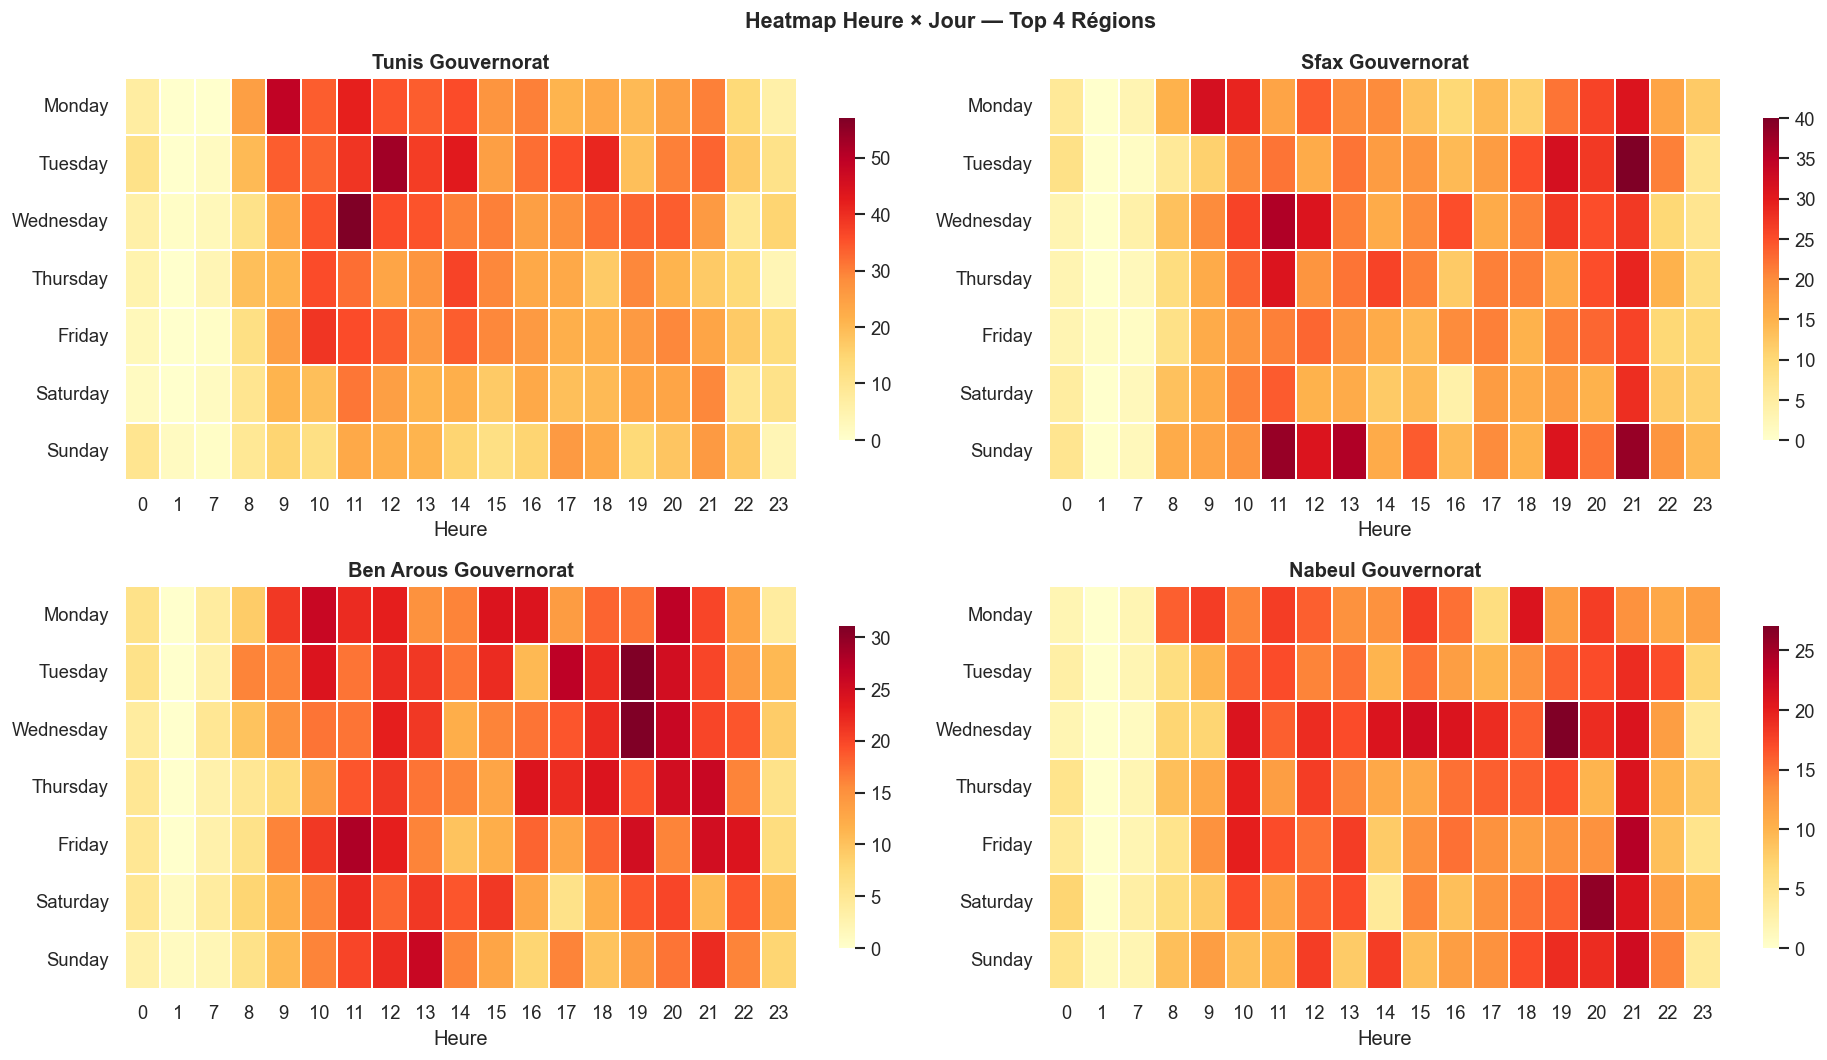

In [47]:
# Heatmap par région — top 4
top4 = results['regional_hotspots']['region'].head(4).tolist()
DOW  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, region in enumerate(top4):
    reg_df = complaints_clean[complaints_clean['region'] == region]
    if 'hour' not in reg_df.columns:
        reg_df = reg_df.copy()
        reg_df['hour']        = reg_df['timestamp'].dt.hour
        reg_df['day_of_week'] = reg_df['timestamp'].dt.day_name()
    pivot = (reg_df.groupby(['day_of_week','hour'])
                    .size().unstack(fill_value=0)
                    .reindex([d for d in DOW if d in reg_df['day_of_week'].unique()]))
    sns.heatmap(pivot, cmap='YlOrRd', ax=axes[i],
                linewidths=0.2, cbar=True, cbar_kws={'shrink':0.8})
    axes[i].set_title(region, fontweight='bold')
    axes[i].set_xlabel('Heure'); axes[i].set_ylabel('')

plt.suptitle('Heatmap Heure × Jour — Top 4 Régions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_hour_dow_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Anomaly Burst Detection

In [48]:
bursts = results['anomaly_bursts']
if bursts.empty:
    print('Aucun burst détecté.')
else:
    print(f'Total : {len(bursts)}  |  Critiques : {(bursts["severity"]=="Critical").sum()}')
    display(bursts[['region','burst_start','burst_end','duration_days',
                    'total_complaints','peak_zscore','severity']].head(15))

Total : 253  |  Critiques : 90


,region,burst_start,burst_end,duration_days,total_complaints,peak_zscore,severity
0,Sfax Gouvernorat,2025-06-08,2025-06-08,1,120,15.68,Critical
1,Béja Gouvernorat,2025-04-19,2025-04-19,1,32,15.21,Critical
2,Jendouba Gouvernorat,2025-02-17,2025-02-17,1,60,14.58,Critical
3,Bizerte Gouvernorat,2025-12-01,2025-12-01,1,37,10.94,Critical
4,Zaghouan Gouvernorat,2025-07-11,2025-07-11,1,20,8.02,Critical
5,Manouba Gouvernorat,2025-06-19,2025-06-25,7,87,7.54,Critical
6,Kebili Gouvernorat,2025-09-14,2025-09-14,1,9,7.07,Critical
7,Ben Arous Gouvernorat,2025-06-23,2025-06-25,3,76,6.69,Critical
8,Kebili Gouvernorat,2025-05-20,2025-05-20,1,8,6.21,Critical
9,Kebili Gouvernorat,2025-04-16,2025-04-17,2,12,6.21,Critical


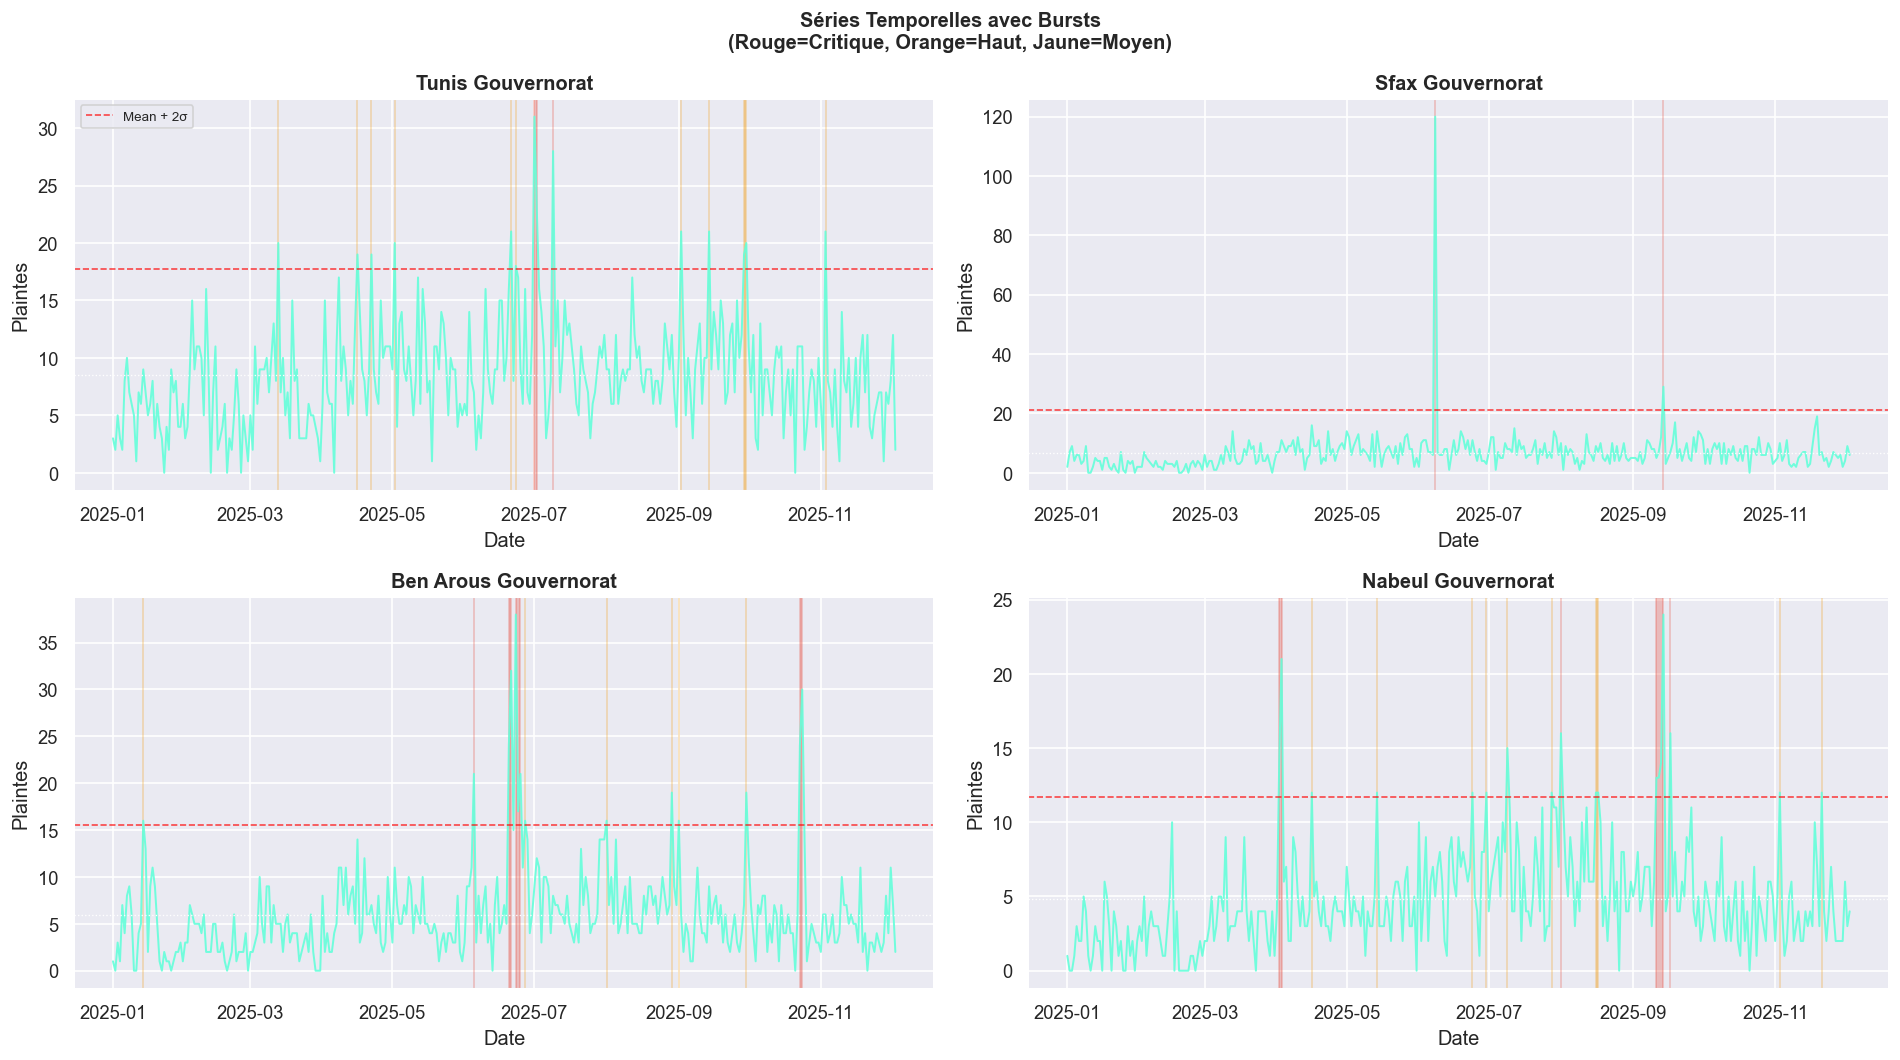

In [49]:
# Séries temporelles avec bursts mis en évidence — top 4 régions
top4 = results['regional_hotspots']['region'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, region in enumerate(top4):
    ca_r = complaint_agg[complaint_agg['region']==region].sort_values('date')
    br   = bursts[bursts['region']==region] if not bursts.empty else pd.DataFrame()

    axes[i].plot(ca_r['date'], ca_r['total_complaints'],
                 color='#64ffda', linewidth=1.2, alpha=0.9)

    if not br.empty:
        for _, burst in br.iterrows():
            color = '#e74c3c' if burst['severity']=='Critical' else \
                    '#f39c12' if burst['severity']=='High'     else '#f1c40f'
            axes[i].axvspan(pd.Timestamp(burst['burst_start']),
                pd.Timestamp(burst['burst_end']),
                            alpha=0.3, color=color)

    m = ca_r['total_complaints'].mean()
    s = ca_r['total_complaints'].std()
    axes[i].axhline(m + 2*s, color='red', linestyle='--', linewidth=1,
                    alpha=0.7, label='Mean + 2σ')
    axes[i].axhline(m, color='white', linestyle=':', linewidth=0.8)
    axes[i].set_title(region, fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel('Plaintes')
    if i == 0: axes[i].legend(fontsize=8)

plt.suptitle('Séries Temporelles avec Bursts\n(Rouge=Critique, Orange=Haut, Jaune=Moyen)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_burst_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

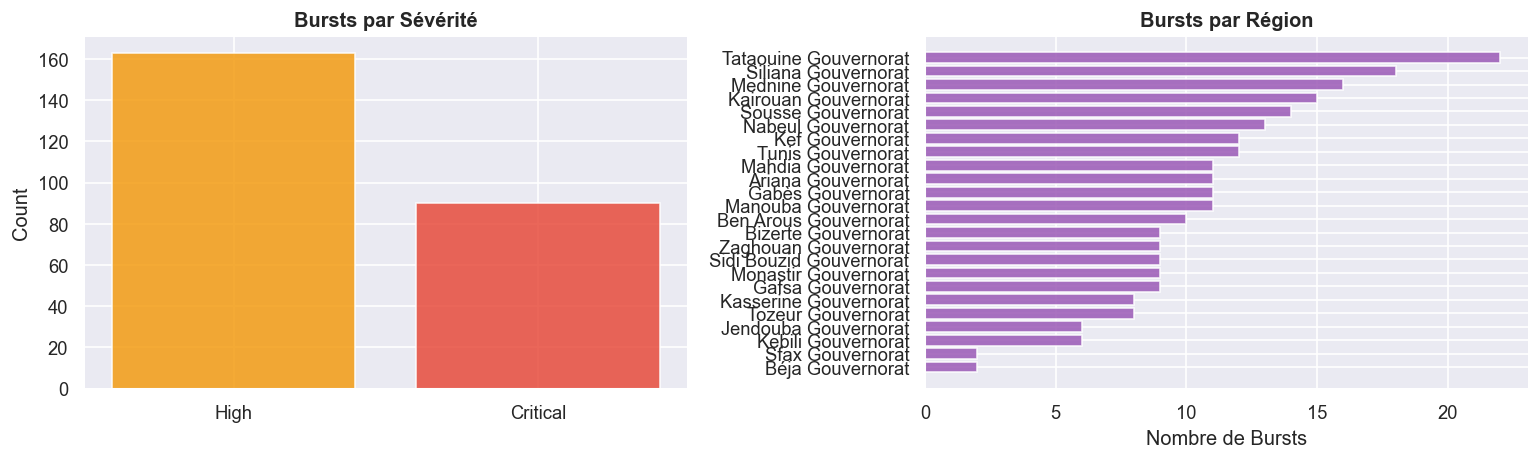

In [50]:
if not bursts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sev = bursts['severity'].value_counts()
    colors = ['#e74c3c' if s=='Critical' else '#f39c12' if s=='High' else '#f1c40f'
              for s in sev.index]
    axes[0].bar(sev.index, sev.values, color=colors, alpha=0.85)
    axes[0].set_title('Bursts par Sévérité', fontweight='bold')
    axes[0].set_ylabel('Count')

    bpr = bursts.groupby('region').size().sort_values()
    axes[1].barh(bpr.index, bpr.values, color='#9b59b6', alpha=0.85)
    axes[1].set_title('Bursts par Région', fontweight='bold')
    axes[1].set_xlabel('Nombre de Bursts')

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_burst_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Service-Type Segmentation by Region

In [51]:
svc = results['service_by_region']
display(svc)

service_type,region,Data,Voice,Data_pct,Voice_pct,dominant_service
0,Ariana Gouvernorat,749,530,58.6,41.4,Data
1,Ben Arous Gouvernorat,1252,752,62.5,37.5,Data
2,Bizerte Gouvernorat,705,450,61.0,39.0,Data
3,Béja Gouvernorat,241,148,62.0,38.0,Data
4,Gabès Gouvernorat,433,208,67.6,32.4,Data
5,Gafsa Gouvernorat,650,439,59.7,40.3,Data
6,Jendouba Gouvernorat,441,235,65.2,34.8,Data
7,Kairouan Gouvernorat,544,324,62.7,37.3,Data
8,Kasserine Gouvernorat,486,285,63.0,37.0,Data
9,Kebili Gouvernorat,170,100,63.0,37.0,Data


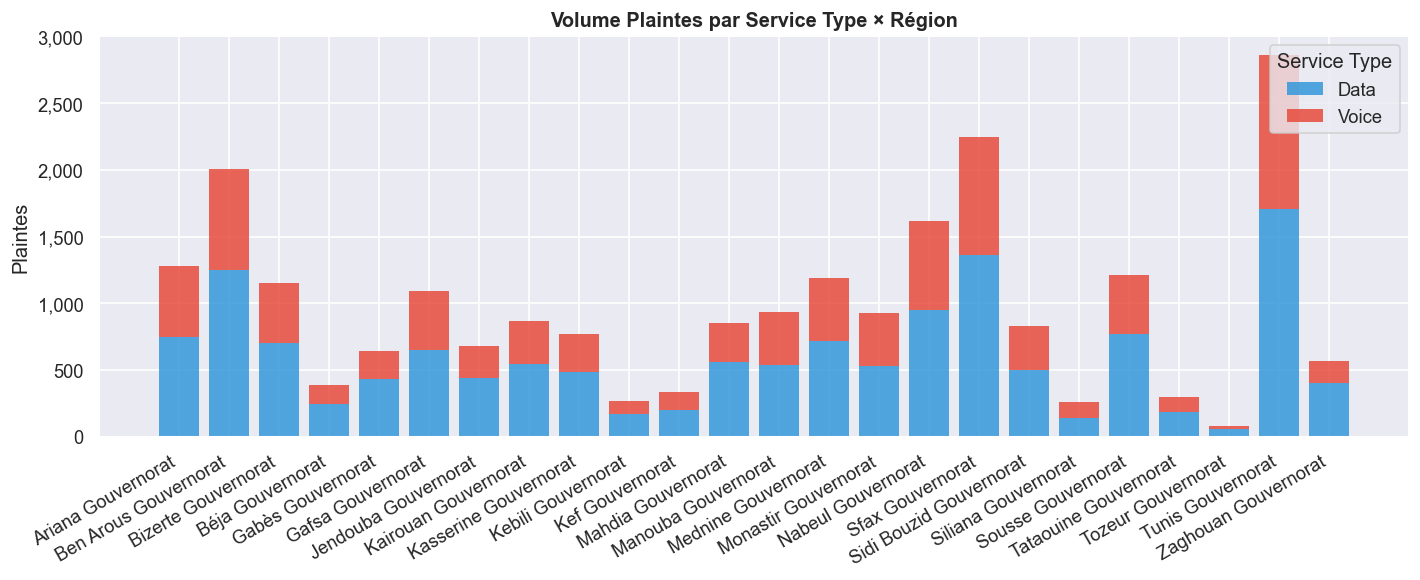

In [52]:
# Stacked bar Data vs Voice par région
svc_cols = [c for c in svc.columns
            if c not in ('region','dominant_service') and not c.endswith('_pct')]
palette  = {'Data':'#3498db','Voice':'#e74c3c','Unknown':'#95a5a6','SMS':'#2ecc71'}

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(svc))
bottom = np.zeros(len(svc))
for col in svc_cols:
    color = palette.get(col, '#9b59b6')
    ax.bar(x, svc[col], bottom=bottom, label=col,
           color=color, alpha=0.85, edgecolor='none')
    bottom += svc[col].values

ax.set_xticks(x)
ax.set_xticklabels(svc['region'], rotation=30, ha='right')
ax.set_title('Volume Plaintes par Service Type × Région', fontweight='bold')
ax.set_ylabel('Plaintes'); ax.legend(title='Service Type', loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_service_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

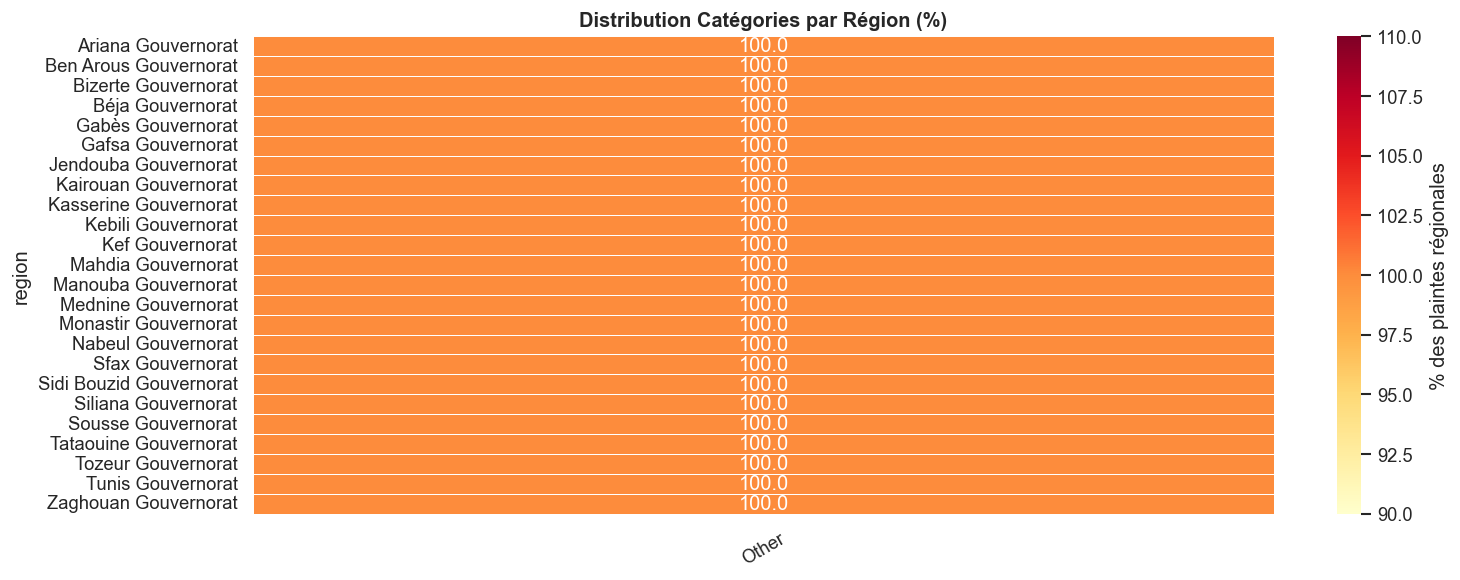

In [53]:
# Heatmap catégorie × région
cat_cols  = [c for c in complaint_agg.columns if c.startswith('cat_')]
cat_pivot = complaint_agg.groupby('region')[cat_cols].sum()
cat_pivot.columns = [c.replace('cat_','').replace('_',' ').title()
                     for c in cat_pivot.columns]
cat_norm  = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(cat_norm, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': '% des plaintes régionales'})
ax.set_title('Distribution Catégories par Région (%)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIGURES}/st_category_by_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cell-Level Hotspot Analysis

In [54]:
cells = results['cell_hotspots']
print('=== Analyse Cell-Level ===')
if cells.empty:
    print('  Pas de colonne cell_id dans les données DCLM réelles.')
    print('  → Section skippée. Analyse disponible au niveau région uniquement.')
    print('  → Avec des données contenant un identifiant de cellule,'
          ' cette section affichera le top 20 cellules.')
else:
    display(cells[['cell_rank','cell_id','region',
                   'total_complaints','dominant_category']].to_string(index=False))


=== Analyse Cell-Level ===
  Pas de colonne cell_id dans les données DCLM réelles.
  → Section skippée. Analyse disponible au niveau région uniquement.
  → Avec des données contenant un identifiant de cellule, cette section affichera le top 20 cellules.


  Graphique cell-level non disponible (pas de cell_id dans les données).

  → Affichage alternatif : Top 15 sous-catégories de plaintes


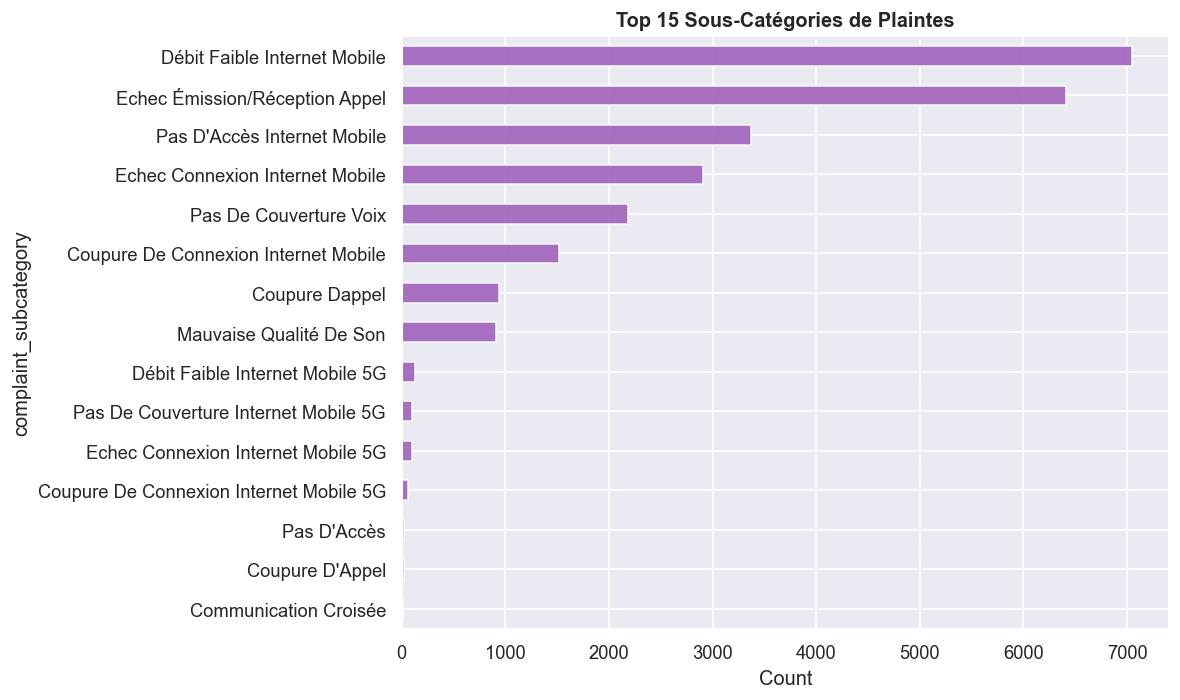

In [55]:
# Top 15 cellules — skippé si pas de cell_id
if cells.empty:
    print('  Graphique cell-level non disponible (pas de cell_id dans les données).')
    print()
    # Afficher à la place le top 15 des sous-catégories
    print('  → Affichage alternatif : Top 15 sous-catégories de plaintes')
    if 'complaint_subcategory' in complaints_clean.columns:
        top15_sub = complaints_clean['complaint_subcategory'].value_counts().head(15)
        fig, ax = plt.subplots(figsize=(10, 6))
        top15_sub.sort_values().plot(kind='barh', ax=ax,
                                     color='#9b59b6', alpha=0.85)
        ax.set_title('Top 15 Sous-Catégories de Plaintes', fontweight='bold')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/st_subcategory_top15.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    top15 = cells.head(15).sort_values('total_complaints')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top15['cell_id'] + ' (' + top15['region'] + ')',
            top15['total_complaints'],
            color=COLORS[:len(top15)], edgecolor='none', alpha=0.85)
    ax.set_title('Top 15 Cellules par Volume de Plaintes', fontweight='bold')
    ax.set_xlabel('Total Plaintes')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_cell_hotspots.png', dpi=150, bbox_inches='tight')
    plt.show()


  Tendance cell-level non disponible (pas de cell_id dans les données).

  → Affichage alternatif : Tendance hebdomadaire — Top 3 régions


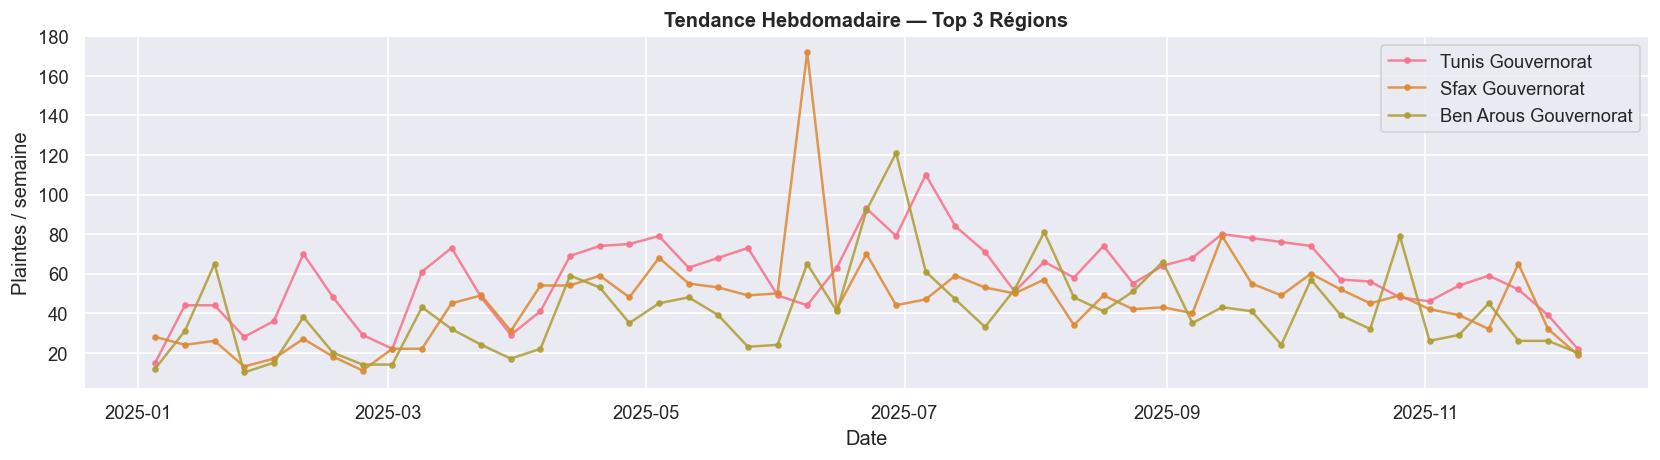

In [56]:
# Tendance hebdomadaire — top 3 cellules (skippé si pas de cell_id)
if cells.empty or 'cell_id' not in complaints_clean.columns:
    print('  Tendance cell-level non disponible (pas de cell_id dans les données).')
    print()
    # Afficher à la place la tendance par région top 3
    print('  → Affichage alternatif : Tendance hebdomadaire — Top 3 régions')
    top3_regions = results['regional_hotspots']['region'].head(3).tolist()
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, region in enumerate(top3_regions):
        reg_ts = (complaint_agg[complaint_agg['region']==region]
          .sort_values('date')
          .assign(date=lambda d: pd.to_datetime(d['date']))
          .set_index('date')['total_complaints']
          .resample('W').sum().reset_index())
        ax.plot(reg_ts['date'], reg_ts['total_complaints'],
                linewidth=1.5, marker='o', markersize=3,
                color=COLORS[i], label=region, alpha=0.85)
    ax.set_title('Tendance Hebdomadaire — Top 3 Régions', fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Plaintes / semaine')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_region_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    top3_cells = cells.head(3)['cell_id'].tolist()
    complaints_clean['date'] = complaints_clean['timestamp'].dt.date
    cell_trend = (
        complaints_clean[complaints_clean['cell_id'].isin(top3_cells)]
        .groupby(['date','cell_id']).size().reset_index(name='count')
    )
    cell_trend['date'] = pd.to_datetime(cell_trend['date'])
    cell_trend_w = (
        cell_trend.set_index('date').groupby('cell_id')['count']
                   .resample('W').sum().reset_index()
    )
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, cell in enumerate(top3_cells):
        ct = cell_trend_w[cell_trend_w['cell_id'] == cell]
        ax.plot(ct['date'], ct['count'], linewidth=1.5,
                marker='o', markersize=3,
                color=COLORS[i], label=cell, alpha=0.85)
    ax.set_title('Tendance Hebdomadaire — Top 3 Cellules', fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Plaintes / semaine')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/st_cell_trend.png', dpi=150, bbox_inches='tight')
    plt.show()


## 8. Synthèse — D3 Part 1

In [57]:
summary = results['summary']

print('=' * 60)
print('  SPATIO-TEMPORAL — RÉSULTATS CLÉS')
print('=' * 60)

if 'top_hotspot_region' in summary:
    print(f'\n  Hotspot géographique :')
    print(f'    Région top     : {summary["top_hotspot_region"]}')
    print(f'    Volume total   : {summary["top_hotspot_complaints"]:,} plaintes')
    print(f'    Problème dom.  : {summary["top_hotspot_category"]}')

if 'peak_hour' in summary:
    print(f'\n  Patterns temporels :')
    print(f'    Heure de pointe  : {summary["peak_hour"]:02d}h00 ({summary["peak_hour_label"]})')
    print(f'    Ratio peak/off   : {summary["peak_offpeak_ratio"]:.2f}x plus de plaintes')

if 'total_burst_events' in summary:
    print(f'\n  Anomalies burst :')
    print(f'    Total           : {summary["total_burst_events"]}')
    print(f'    Critiques       : {summary["critical_bursts"]}')
    print(f'    Région la + bursty : {summary["most_bursty_region"]}')

import os
st_files = sorted([f for f in os.listdir('reports/exports') if f.startswith('st_')])
print(f'\n  Fichiers sauvés ({len(st_files)}) :')
for f in st_files:
    print(f'    reports/exports/{f}')

figs = sorted([f for f in os.listdir('reports/figures') if f.startswith('st_')])
print(f'\n  Figures ({len(figs)}) :')
for f in figs:
    print(f'    reports/figures/{f}')
print('=' * 60)
print('\n→ Prêt pour Notebook 04 — Correlation & Root Cause ✓')

  SPATIO-TEMPORAL — RÉSULTATS CLÉS

  Hotspot géographique :
    Région top     : Tunis Gouvernorat
    Volume total   : 2,859 plaintes
    Problème dom.  : Other

  Patterns temporels :
    Heure de pointe  : 19h00 (Evening (17-20))
    Ratio peak/off   : 1.03x plus de plaintes

  Anomalies burst :
    Total           : 253
    Critiques       : 90
    Région la + bursty : Tataouine Gouvernorat

  Fichiers sauvés (7) :
    reports/exports/st_anomaly_bursts.csv
    reports/exports/st_dow_patterns.csv
    reports/exports/st_hourly_patterns.csv
    reports/exports/st_monthly_trends.csv
    reports/exports/st_regional_hotspots.csv
    reports/exports/st_regional_map.html
    reports/exports/st_service_by_region.csv

  Figures (13) :
    reports/figures/st_bubble_map.png
    reports/figures/st_burst_analysis.png
    reports/figures/st_burst_timeseries.png
    reports/figures/st_category_by_region_heatmap.png
    reports/figures/st_cell_hotspots.png
    reports/figures/st_hour_dow_by_region